[ 11.4375  34.3125  57.1875  80.0625 102.9375 125.8125 148.6875 171.5625
 194.4375 217.3125 240.1875 263.0625 285.9375 308.8125 331.6875 354.5625]
[openmc.deplete] t=0.0 s, dt=43200.0 s, source=18894.637461958508


/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


[openmc.deplete] t=43200.0 (final operator evaluation)
[openmc.deplete] t=0.0 s, dt=43200.0 s, source=18894.637461958508
[openmc.deplete] t=43200.0 (final operator evaluation)
[openmc.deplete] t=0.0 s, dt=43200.0 s, source=18894.637461958508
[openmc.deplete] t=43200.0 (final operator evaluation)
[openmc.deplete] t=0.0 s, dt=43200.0 s, source=18894.637461958508
[openmc.deplete] t=43200.0 (final operator evaluation)
[openmc.deplete] t=0.0 s, dt=43200.0 s, source=18894.637461958508
[openmc.deplete] t=43200.0 (final operator evaluation)
[openmc.deplete] t=0.0 s, dt=86400 s, source=18894.637461958508
[openmc.deplete] t=86400.0 (final operator evaluation)
[openmc.deplete] t=0.0 s, dt=86400 s, source=18894.637461958508
[openmc.deplete] t=86400.0 (final operator evaluation)
[openmc.deplete] t=0.0 s, dt=86400 s, source=18894.637461958508
[openmc.deplete] t=86400.0 (final operator evaluation)
[openmc.deplete] t=0.0 s, dt=86400 s, source=18894.637461958508
[openmc.deplete] t=86400.0 (final operat

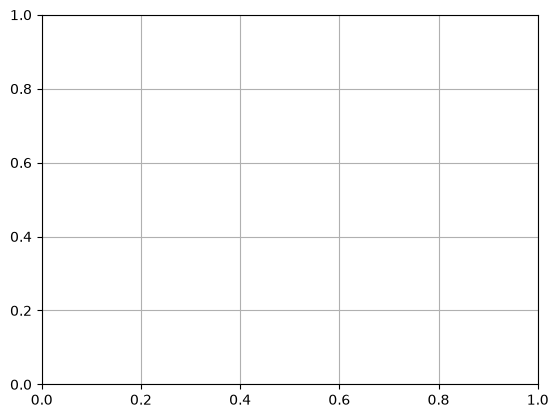

In [1]:
import CustomSchemes
import CustomSchemes.data.pwr_rei_template as pwr
import openmc
import openmc.deplete
import numpy as np
import copy
import logging 
import pickle as pkl
import glob
import os
import sys
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
openmc.deplete.pool.USE_MULTIPROCESSING=False

from CustomSchemes.AA import Anderson
from CustomSchemes.TransportMath import run_transport, run_transport_for_chain, run_transport_standard
from CustomSchemes.DumbTransport import transport as dummy_transport
from CustomSchemes.NuclideVectorMath import get_nuclides_for_transport, \
    make_transport_material_library, \
    get_depletion_materials_from_results_EOS, \
    chain_from_pkl, \
    depletable_mats_from_model, \
    make_transport_material_library, \
    relax_nuclides_from_files


"""
Setup logging
"""
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s', filemode='a', filename="LOGGING.LOG")
logging.getLogger().setLevel(logging.DEBUG)
logging.info(f"Now running input....")


# Input stuff
micro_xs = chain_from_pkl(file=str(Path(CustomSchemes.data.__file__).parent / "FINAL_CHAIN.pkl")) # get xs from a reference file
chain_file = str(Path(CustomSchemes.data.__file__).parent / "chain_casl_pwr.xml")

dt = [0.5, 1, 1.5, 2, 5, 10, 10, 10, 10,
25, 25, 25, 25,
25, 25, 25, 25,
25, 25, 25, 25] # up to 350 days
dt = [0.5,1]
model = pwr.get_model()

# Computing the power density to use
fuel_r=0.3975
power_density = 104
power = power_density * 366  * np.pi * fuel_r**2

# Random stuff - non-strictly-input-based
depletion_materials = depletable_mats_from_model(model=model) # get from starting model
depl_id_list = [this.id for this in depletion_materials]

# Robbins Monro related
fake_transport = True
nsolves = 4 # number of transport solves/solution
andersonOrder = 2
aa = Anderson(mr=andersonOrder, tolerance=1e-15, max_solves=4, dummy_transport=fake_transport)

"""Make the results folder"""
Path("results").mkdir(parents=True, exist_ok=True)
Path("depl_results").mkdir(parents=True, exist_ok=True)

"""Start by performing t=0 transport"""
aa.initialize_bos()

# actual transport
if fake_transport:
  LATEST_FLUX = dummy_transport(N=len(depl_id_list))
# actual transport
else:
  RESULTS_TRANSPORT = run_transport_standard(model=model, power_tally_ids=depl_id_list) ## transport w/ batch-by-batch tally tracking
  LATEST_FLUX = aa.get_final_tally(res=RESULTS_TRANSPORT, normalize_to=1.0)

aa.finalize_bos(x=[LATEST_FLUX])
aa.dump_to_pkl(name=aa.get_pickle_name(k=0, tidx=0))

"""iterate through time"""
the_eos_time = 0.0
for _tidx, this_dt in enumerate(dt):
  # Time
  TIME_IDX = _tidx + 1
  the_eos_time += this_dt

  aa.initialize_step(time=the_eos_time)
  LATEST_FLUX = aa.solve_step(
    initial_x=LATEST_FLUX, 
    tidx=TIME_IDX, 
    depl_mats=depletion_materials, model=model, micro_xs=micro_xs,chain_file=chain_file,
    dt=this_dt, power=power, depl_id_list=depl_id_list, time=the_eos_time
  )
  depletion_materials = get_depletion_materials_from_results_EOS(output_name=aa.depl_output, model=model)



In [2]:
aa.x[0]

[array([0.05708748, 0.06822516, 0.06276105, 0.05643479, 0.06534322,
        0.06760754, 0.05932674, 0.05820931, 0.06760056, 0.05735002,
        0.05814129, 0.06449507, 0.06632597, 0.06000325, 0.06837767,
        0.06271089])]

In [11]:
aa.fx[0.5]

[array([0.05947647, 0.05868295, 0.06354464, 0.0665503 , 0.06290992,
        0.06676216, 0.06706273, 0.06489092, 0.06656397, 0.06245705,
        0.05878656, 0.05889464, 0.0579277 , 0.06278207, 0.05541821,
        0.06728972]),
 array([0.05864832, 0.06121566, 0.05905327, 0.06552976, 0.05881491,
        0.05961618, 0.06594304, 0.06734132, 0.06266278, 0.06704127,
        0.06669956, 0.0579844 , 0.06209675, 0.06843575, 0.05825674,
        0.06066029]),
 array([0.05720305, 0.0599803 , 0.06595728, 0.06487116, 0.06314436,
        0.06150016, 0.06513785, 0.05962715, 0.0604233 , 0.06838655,
        0.05901193, 0.06771936, 0.06251856, 0.06127662, 0.05975358,
        0.06348878]),
 array([0.057962  , 0.06859359, 0.06331153, 0.06341026, 0.06095772,
        0.05955403, 0.06472876, 0.06055845, 0.06115099, 0.05887712,
        0.05780061, 0.06434163, 0.06726498, 0.05999217, 0.06441335,
        0.0670828 ])]

In [3]:
aa.x[0.5]

[array([0.05708748, 0.06822516, 0.06276105, 0.05643479, 0.06534322,
        0.06760754, 0.05932674, 0.05820931, 0.06760056, 0.05735002,
        0.05814129, 0.06449507, 0.06632597, 0.06000325, 0.06837767,
        0.06271089]),
 array([0.05947647, 0.05868295, 0.06354464, 0.0665503 , 0.06290992,
        0.06676216, 0.06706273, 0.06489092, 0.06656397, 0.06245705,
        0.05878656, 0.05889464, 0.0579277 , 0.06278207, 0.05541821,
        0.06728972]),
 array([0.0589339 , 0.06034227, 0.0606021 , 0.06588169, 0.06022706,
        0.06208043, 0.06632916, 0.06649631, 0.06400808, 0.06546043,
        0.0639708 , 0.05829829, 0.06065907, 0.06648611, 0.05727788,
        0.06294641]),
 array([0.05819984, 0.06009882, 0.06310768, 0.06547097, 0.06164679,
        0.06206262, 0.06584219, 0.0633924 , 0.06256043, 0.06659557,
        0.06152587, 0.06247386, 0.06133869, 0.064006  , 0.05827286,
        0.0634054 ]),
 array([0.05795373, 0.06243105, 0.06259382, 0.06480285, 0.06091534,
        0.06030427, 0.065367

In [4]:
aa.k

{0.0: -1, 0.5: 4, 1.5: 4}

Computed fixed point (last x_next) =  [0.05795373 0.06243105 0.06259382 0.06480285 0.06091534 0.06030427
 0.06536711 0.06292536 0.06148467 0.06568827 0.06181284 0.06305689
 0.06342789 0.06384945 0.06021308 0.06317337]
Last n_next value from vector x =  [0.05795373 0.06243105 0.06259382 0.06480285 0.06091534 0.06030427
 0.06536711 0.06292536 0.06148467 0.06568827 0.06181284 0.06305689
 0.06342789 0.06384945 0.06021308 0.06317337]
Iterations: 4
Alpha sums are == 1.0
Alphas = [0.40012979 0.37272798 0.22714223]


{0.5: array([0.40012979, 0.37272798, 0.22714223]),
 1.5: array([0.05785934, 0.48656613, 0.45557453])}

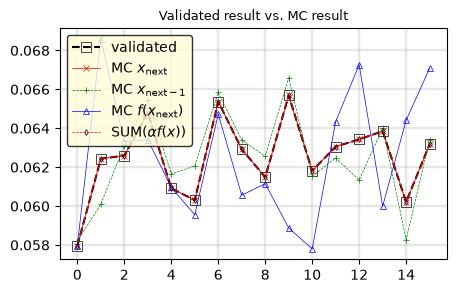

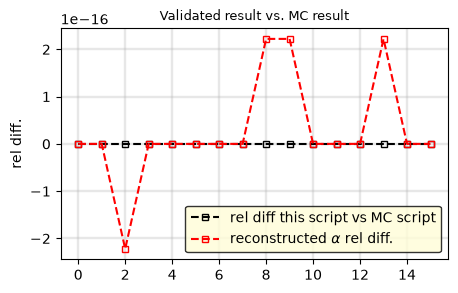

In [5]:
import CustomSchemes.aa_validator as valid
valid.validate_case(time=0.5, file='results/aa2_i4_t2.pkl', k_max=4, m=2, dpi=100)
aa._latest_alpha

In [6]:
aa.x[0.5]

[array([0.05708748, 0.06822516, 0.06276105, 0.05643479, 0.06534322,
        0.06760754, 0.05932674, 0.05820931, 0.06760056, 0.05735002,
        0.05814129, 0.06449507, 0.06632597, 0.06000325, 0.06837767,
        0.06271089]),
 array([0.05947647, 0.05868295, 0.06354464, 0.0665503 , 0.06290992,
        0.06676216, 0.06706273, 0.06489092, 0.06656397, 0.06245705,
        0.05878656, 0.05889464, 0.0579277 , 0.06278207, 0.05541821,
        0.06728972]),
 array([0.0589339 , 0.06034227, 0.0606021 , 0.06588169, 0.06022706,
        0.06208043, 0.06632916, 0.06649631, 0.06400808, 0.06546043,
        0.0639708 , 0.05829829, 0.06065907, 0.06648611, 0.05727788,
        0.06294641]),
 array([0.05819984, 0.06009882, 0.06310768, 0.06547097, 0.06164679,
        0.06206262, 0.06584219, 0.0633924 , 0.06256043, 0.06659557,
        0.06152587, 0.06247386, 0.06133869, 0.064006  , 0.05827286,
        0.0634054 ]),
 array([0.05795373, 0.06243105, 0.06259382, 0.06480285, 0.06091534,
        0.06030427, 0.065367

In [7]:
aa._latest_alpha[0.5]

array([0.40012979, 0.37272798, 0.22714223])

In [8]:
aa._latest_alpha[0.5][2] * aa.fx[0.5][-1] + aa._latest_alpha[0.5][1] * aa.fx[0.5][-2] + aa._latest_alpha[0.5][0] * aa.fx[0.5][-3]

array([0.05795373, 0.06243105, 0.06259382, 0.06480285, 0.06091534,
       0.06030427, 0.06536711, 0.06292536, 0.06148467, 0.06568827,
       0.06181284, 0.06305689, 0.06342789, 0.06384945, 0.06021308,
       0.06317337])

In [9]:
aa.reconstruct_final_x_next_from_alpha(time=0.5)

array([0.05795373, 0.06243105, 0.06259382, 0.06480285, 0.06091534,
       0.06030427, 0.06536711, 0.06292536, 0.06148467, 0.06568827,
       0.06181284, 0.06305689, 0.06342789, 0.06384945, 0.06021308,
       0.06317337])

In [ ]:
import CustomSchemes.SIE as SIE

SIE.SIE().get_from_pkl("FLUX.pkl").x[0.5]

[array([0.01568987, 0.03854757, 0.05708726, 0.07123094, 0.08129146,
        0.08725667, 0.08979465, 0.09030785, 0.08857304, 0.08448125,
        0.07834931, 0.07006382, 0.05937664, 0.04595074, 0.03001021,
        0.01198871]),
 array([0.01606339, 0.03943435, 0.05862808, 0.07320148, 0.08328401,
        0.08908878, 0.09129201, 0.0909413 , 0.08831184, 0.08358993,
        0.07679381, 0.06812276, 0.05719928, 0.04400556, 0.02862492,
        0.0114185 ]),
 array([0.01592029, 0.0391119 , 0.05816829, 0.07270747, 0.08284728,
        0.08885975, 0.09133006, 0.09117785, 0.08878083, 0.08403529,
        0.07715464, 0.06834677, 0.05728697, 0.04408697, 0.02871327,
        0.01147237]),
 array([0.01601353, 0.03925758, 0.05830794, 0.07275894, 0.08277035,
        0.08874447, 0.09123579, 0.09104447, 0.0885108 , 0.08381558,
        0.07698913, 0.06824821, 0.05742598, 0.04432616, 0.02896768,
        0.0115834 ])]